In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
MODEL_NAME = "ResNet50"
INPUT_SIZE = (224, 224)
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
MAX_EPOCHS = 30
SEED = 42
CLASS_NAMES = ["Fake", "Real"]  # urutan label: Fake=0, Real=1

DATASET_PATH = "/content/drive/MyDrive/JurnalKapisel/Dataset"
TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
VAL_DIR = os.path.join(DATASET_PATH, "Validation")
TEST_DIR = os.path.join(DATASET_PATH, "Test")

OUTPUT_DIR = f"/content/drive/MyDrive/JurnalKapisel/Hasil_Eksperimen/{MODEL_NAME}"
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
HISTORY_DIR = os.path.join(OUTPUT_DIR, "history")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
for d in [CHECKPOINT_DIR, HISTORY_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def make_dataset(directory, shuffle=False, augment=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        image_size=INPUT_SIZE,
        shuffle=shuffle,
        seed=SEED,
        interpolation="bilinear",
    )

    if augment:
        data_augmentation = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ], name="data_augmentation")
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

print(f"\nMembuat dataset untuk {MODEL_NAME} (input_size={INPUT_SIZE}) ...")
train_ds = make_dataset(TRAIN_DIR, shuffle=True, augment=True)
val_ds = make_dataset(VAL_DIR, shuffle=False, augment=False)
test_ds = make_dataset(TEST_DIR, shuffle=False, augment=False)

# Validasi cepat satu batch
for images, labels in train_ds.take(1):
    print(f"Batch shape gambar : {images.shape}")
    print(f"Range nilai piksel : min={images.numpy().min():.2f}, max={images.numpy().max():.2f}")
    print(f"Contoh label       : {labels.numpy()[:8].flatten()}")


Membuat dataset untuk ResNet50 (input_size=(224, 224)) ...
Found 3708 files belonging to 2 classes.
Found 2243 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Batch shape gambar : (32, 224, 224, 3)
Range nilai piksel : min=-123.68, max=151.06
Contoh label       : [0. 1. 1. 1. 0. 0. 0. 0.]


In [ ]:
input_shape = INPUT_SIZE + (3,)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape,
)
base_model.trainable = False  # feature extraction: freeze base model

inputs = tf.keras.Input(shape=input_shape)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dense(256, activation="relu", name="dense_head")(x)
x = layers.BatchNormalization(name="bn_head")(x)
x = layers.Dropout(0.4, name="dropout_head")(x)
outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

model = models.Model(inputs, outputs, name=f"{MODEL_NAME}_deepfake_detector")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()

n_trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
n_nontrainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\nParameter trainable     : {n_trainable:,}")
print(f"Parameter non-trainable : {n_nontrainable:,}")


Model: "ResNet50_deepfake_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)


Parameter trainable     : 525,313
Parameter non-trainable : 23,588,224


In [ ]:
checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_best.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1),
]

In [ ]:
print(f"\n{'='*70}\nMULAI TRAINING: {MODEL_NAME}\n{'='*70}")

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
train_duration = time.time() - start_time
print(f"\nTotal waktu training: {train_duration/60:.1f} menit "
      f"({len(history.history['loss'])} epoch)")

# Simpan history training
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(os.path.join(HISTORY_DIR, f"{MODEL_NAME}_history.csv"), index=False)



MULAI TRAINING: ResNet50
Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6093 - auc: 0.6373 - loss: 0.7951 - precision: 0.5971 - recall: 0.6149
Epoch 1: val_loss improved from None to 0.48980, saving model to /content/drive/MyDrive/JurnalKapisel/Hasil_Eksperimen/ResNet50/checkpoints/ResNet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/JurnalKapisel/Hasil_Eksperimen/ResNet50/checkpoints/ResNet50_best.keras
116/116 ━━━━━━━━━━━━━━━━━━━━ 673s 6s/step - accuracy: 0.6494 - auc: 0.6961 - loss: 0.7239 - precision: 0.6483 - recall: 0.6546 - val_accuracy: 0.7646 - val_auc: 0.0000e+00 - val_loss: 0.4898 - val_precision: 1.0000 - val_recall: 0.7646 - learning_rate: 1.0000e-04
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7082 - auc: 0.7852 - loss: 0.5935 - precision: 0.6938 - recall: 0.7287
Epoch 2: val_loss improved from 0.48980 to 0.43350, saving model to /content/drive/MyDrive/JurnalKapisel/Hasil_Eksperimen/ResNet50/checkpoints/Re

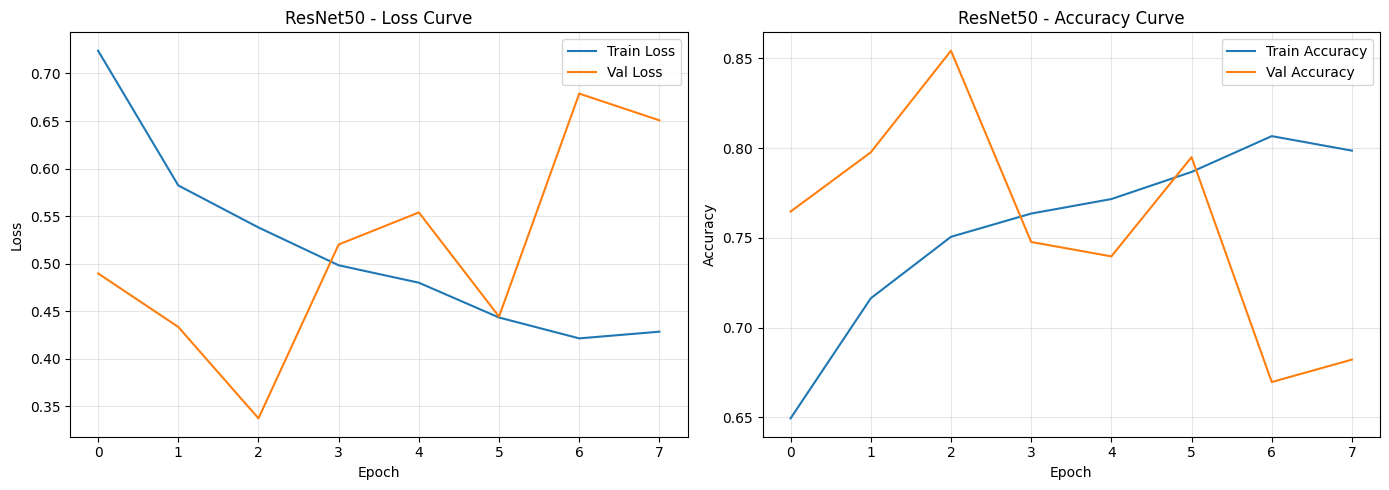

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} - Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} - Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, f"{MODEL_NAME}_training_curves.png"), dpi=150)
plt.show()


Evaluasi ResNet50 pada Test Set...
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.7150 - auc: 0.8341 - loss: 0.5621 - precision: 0.6667 - recall: 0.8600
{'accuracy': 0.7149999737739563, 'auc': 0.8341156244277954, 'loss': 0.5620851516723633, 'precision': 0.6666666865348816, 'recall': 0.8600000143051147}


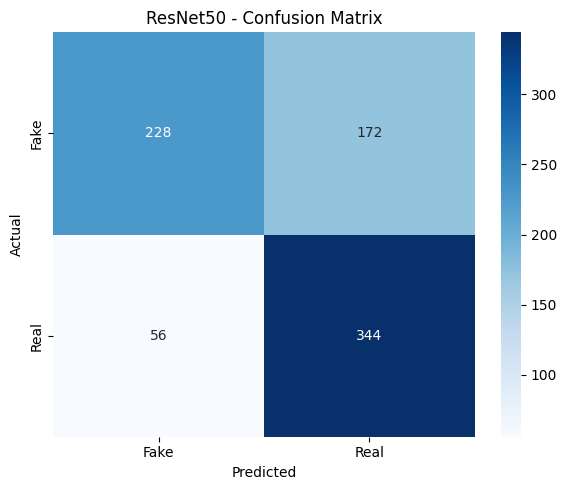

In [ ]:
print(f"\nEvaluasi {MODEL_NAME} pada Test Set...")
test_results = model.evaluate(test_ds, verbose=1, return_dict=True)
print(test_results)

# Prediksi untuk confusion matrix, classification report, ROC curve
y_true = []
y_pred_prob = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"{MODEL_NAME} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, f"{MODEL_NAME}_confusion_matrix.png"), dpi=150)
plt.show()


              precision    recall  f1-score   support

        Fake       0.80      0.57      0.67       400
        Real       0.67      0.86      0.75       400

    accuracy                           0.71       800
   macro avg       0.73      0.71      0.71       800
weighted avg       0.73      0.71      0.71       800



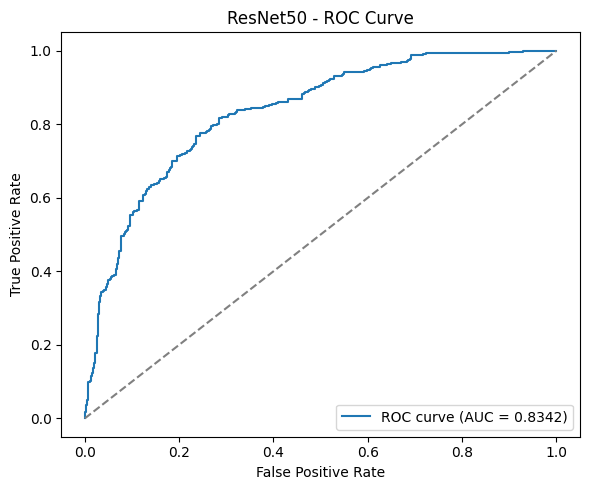

In [ ]:
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                     output_dict=True)
report_str = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report_str)
with open(os.path.join(HISTORY_DIR, f"{MODEL_NAME}_classification_report.txt"), "w") as f:
    f.write(report_str)

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{MODEL_NAME} - ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, f"{MODEL_NAME}_roc_curve.png"), dpi=150)
plt.show()

In [ ]:
summary = {
    "model_name": MODEL_NAME,
    "input_size": INPUT_SIZE,
    "train_duration_seconds": round(train_duration, 2),
    "epochs_run": len(history.history["loss"]),
    "test_results": test_results,
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "trainable_params": int(n_trainable),
    "nontrainable_params": int(n_nontrainable),
}
with open(os.path.join(HISTORY_DIR, f"{MODEL_NAME}_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

final_model_path = os.path.join(CHECKPOINT_DIR, f"{MODEL_NAME}_final.keras")
model.save(final_model_path)

print(f"\n✅ {MODEL_NAME} SELESAI")
print(f"   Waktu training : {train_duration/60:.1f} menit")
print(f"   Test Accuracy  : {test_results['accuracy']:.4f}")
print(f"   Test Precision : {test_results['precision']:.4f}")
print(f"   Test Recall    : {test_results['recall']:.4f}")
print(f"   Test AUC       : {test_results['auc']:.4f}")
print(f"   Semua hasil disimpan di: {OUTPUT_DIR}")


✅ ResNet50 SELESAI
   Waktu training : 18.8 menit
   Test Accuracy  : 0.7150
   Test Precision : 0.6667
   Test Recall    : 0.8600
   Test AUC       : 0.8341
   Semua hasil disimpan di: /content/drive/MyDrive/JurnalKapisel/Hasil_Eksperimen/ResNet50
